In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("https://raw.githubusercontent.com/4GeeksAcademy/logistic-regression-project-tutorial/main/bank-marketing-campaign-data.csv", sep=';')
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [3]:
df.shape

(41188, 21)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [5]:
duplicados = df.duplicated()
num_duplicados = duplicados.sum()
print(num_duplicados)

12


In [6]:
df = df.drop_duplicates()


In [7]:
df.drop(["day_of_week", "month", "pdays", "previous", "default","duration"], axis = 1, inplace = True)

df.head()

,age,job,marital,education,housing,loan,contact,campaign,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,telephone,1,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,no,no,telephone,1,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,yes,no,telephone,1,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,telephone,1,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,yes,telephone,1,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 41176 entries, 0 to 41187
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41176 non-null  int64  
 1   job             41176 non-null  object 
 2   marital         41176 non-null  object 
 3   education       41176 non-null  object 
 4   housing         41176 non-null  object 
 5   loan            41176 non-null  object 
 6   contact         41176 non-null  object 
 7   campaign        41176 non-null  int64  
 8   poutcome        41176 non-null  object 
 9   emp.var.rate    41176 non-null  float64
 10  cons.price.idx  41176 non-null  float64
 11  cons.conf.idx   41176 non-null  float64
 12  euribor3m       41176 non-null  float64
 13  nr.employed     41176 non-null  float64
 14  y               41176 non-null  object 
dtypes: float64(5), int64(2), object(8)
memory usage: 5.0+ MB


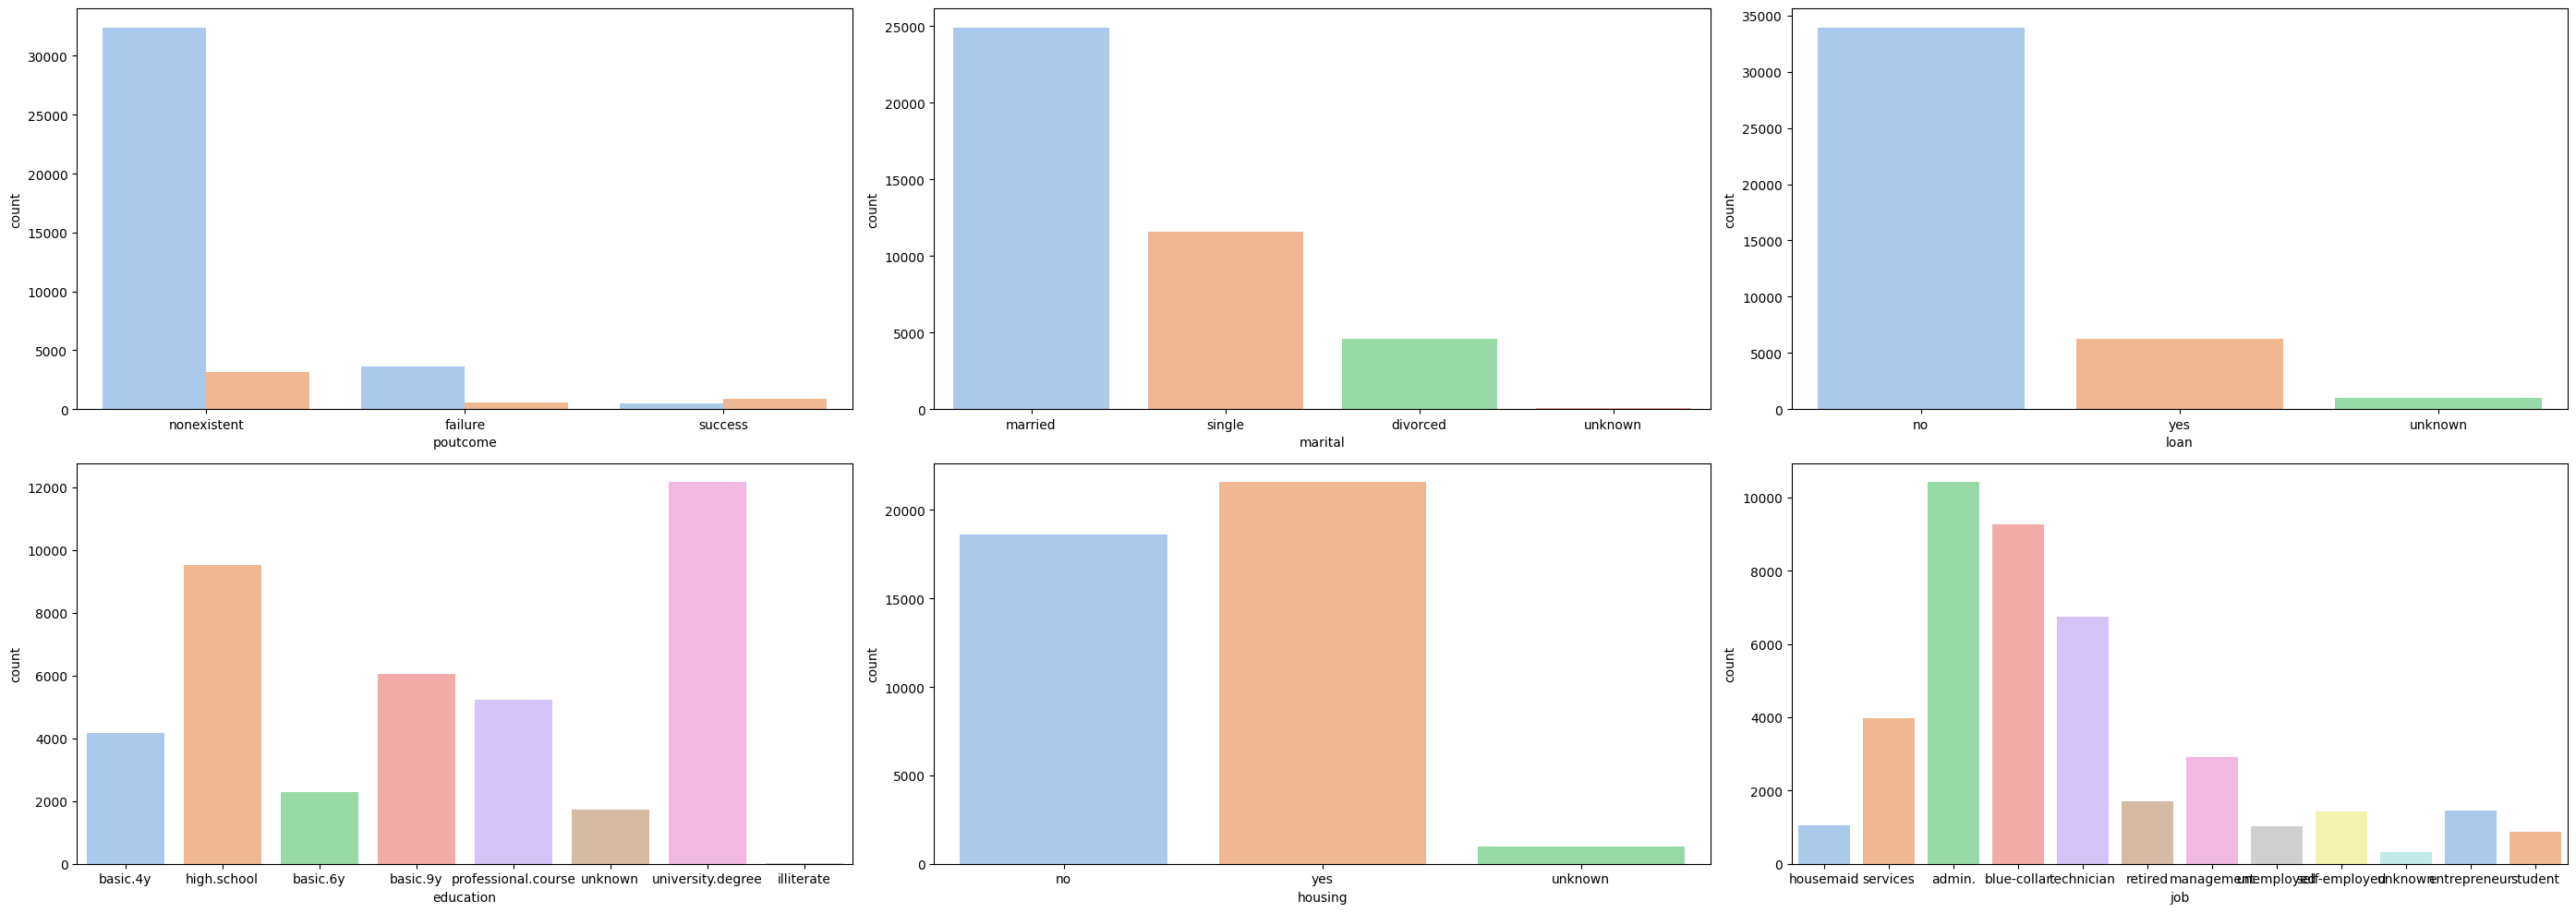

In [9]:
fig, axis = plt.subplots(2, 3, figsize = (28, 10))

sns.countplot(ax = axis[0, 0], data = df, x = "poutcome", palette='pastel', hue= "y", legend=False)
sns.countplot(ax = axis[0, 1], data = df, x = "marital", palette='pastel', hue= "marital", legend=False)
sns.countplot(ax = axis[1, 0], data = df, x = "education", palette='pastel', hue= "education", legend=False)
sns.countplot(ax = axis[1, 1], data = df, x = "housing", palette='pastel', hue= "housing", legend=False)
sns.countplot(ax = axis[0, 2], data = df, x = "loan", palette='pastel', hue= "loan", legend=False)
sns.countplot(ax = axis[1, 2], data = df, x = "job", palette='pastel', hue= "job", legend=False)




plt.tight_layout()

plt.show()

Con estos gráfico podemos ver como en su mayoria son personas casadas y que no cuentan con un prestamo. Además observamos que gran parte tiene una educacion minima de secundaria, sin embargo los datos estan bastante igualados en el gráfico de housing y en cuanto a los trabajos esta bastante repartido aunque hay bastantes en puestos de administración, técnicos y blue collar.

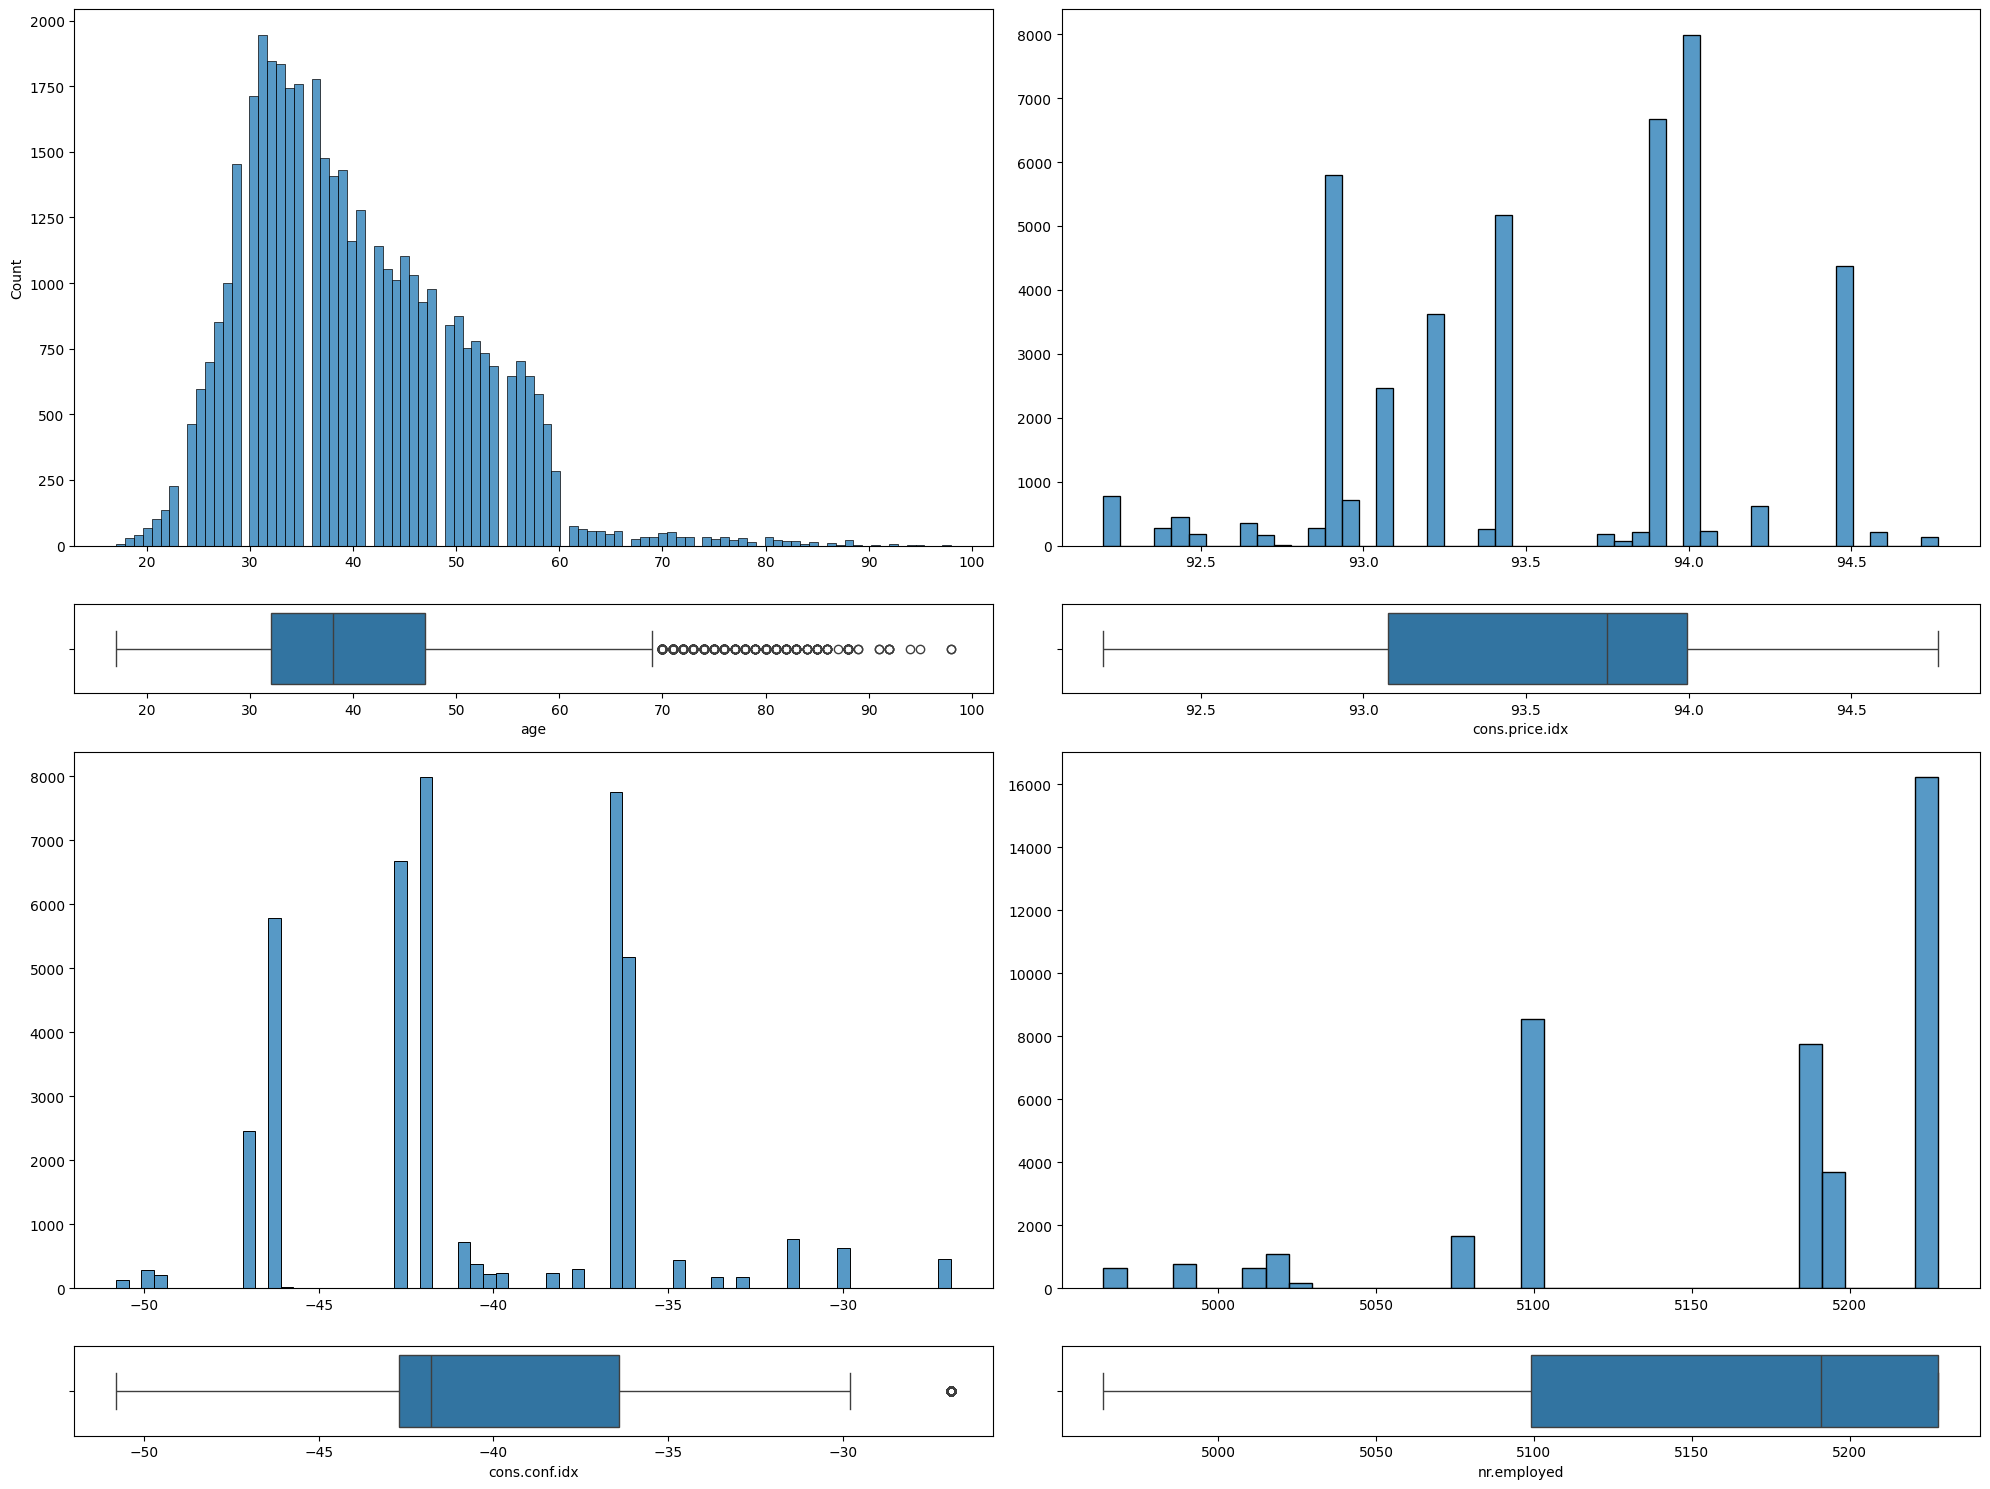

In [10]:


fig, axis = plt.subplots(4, 2, figsize = (20, 15), gridspec_kw = {"height_ratios": [6, 1, 6, 1]})

sns.histplot(ax = axis[0, 0], data = df, x = "age").set(xlabel = None)
sns.boxplot(ax = axis[1, 0], data = df, x = "age")

sns.histplot(ax = axis[0, 1], data = df, x = "cons.price.idx").set(xlabel = None, ylabel = None)
sns.boxplot(ax = axis[1, 1], data = df, x = "cons.price.idx")


sns.histplot(ax = axis[2, 0], data = df, x = "cons.conf.idx").set(xlabel = None, ylabel = None)
sns.boxplot(ax = axis[3, 0], data = df, x = "cons.conf.idx")

sns.histplot(ax = axis[2, 1], data = df, x = "nr.employed").set(xlabel = None, ylabel = None)
sns.boxplot(ax = axis[3, 1], data = df, x = "nr.employed")


plt.tight_layout()

plt.show()

Podemos ver como las edades se condensan entre los 25 y los 60 años y la mediana esta alrededos de los 38 años y vemos valores atípicos a partir de los 70 años.

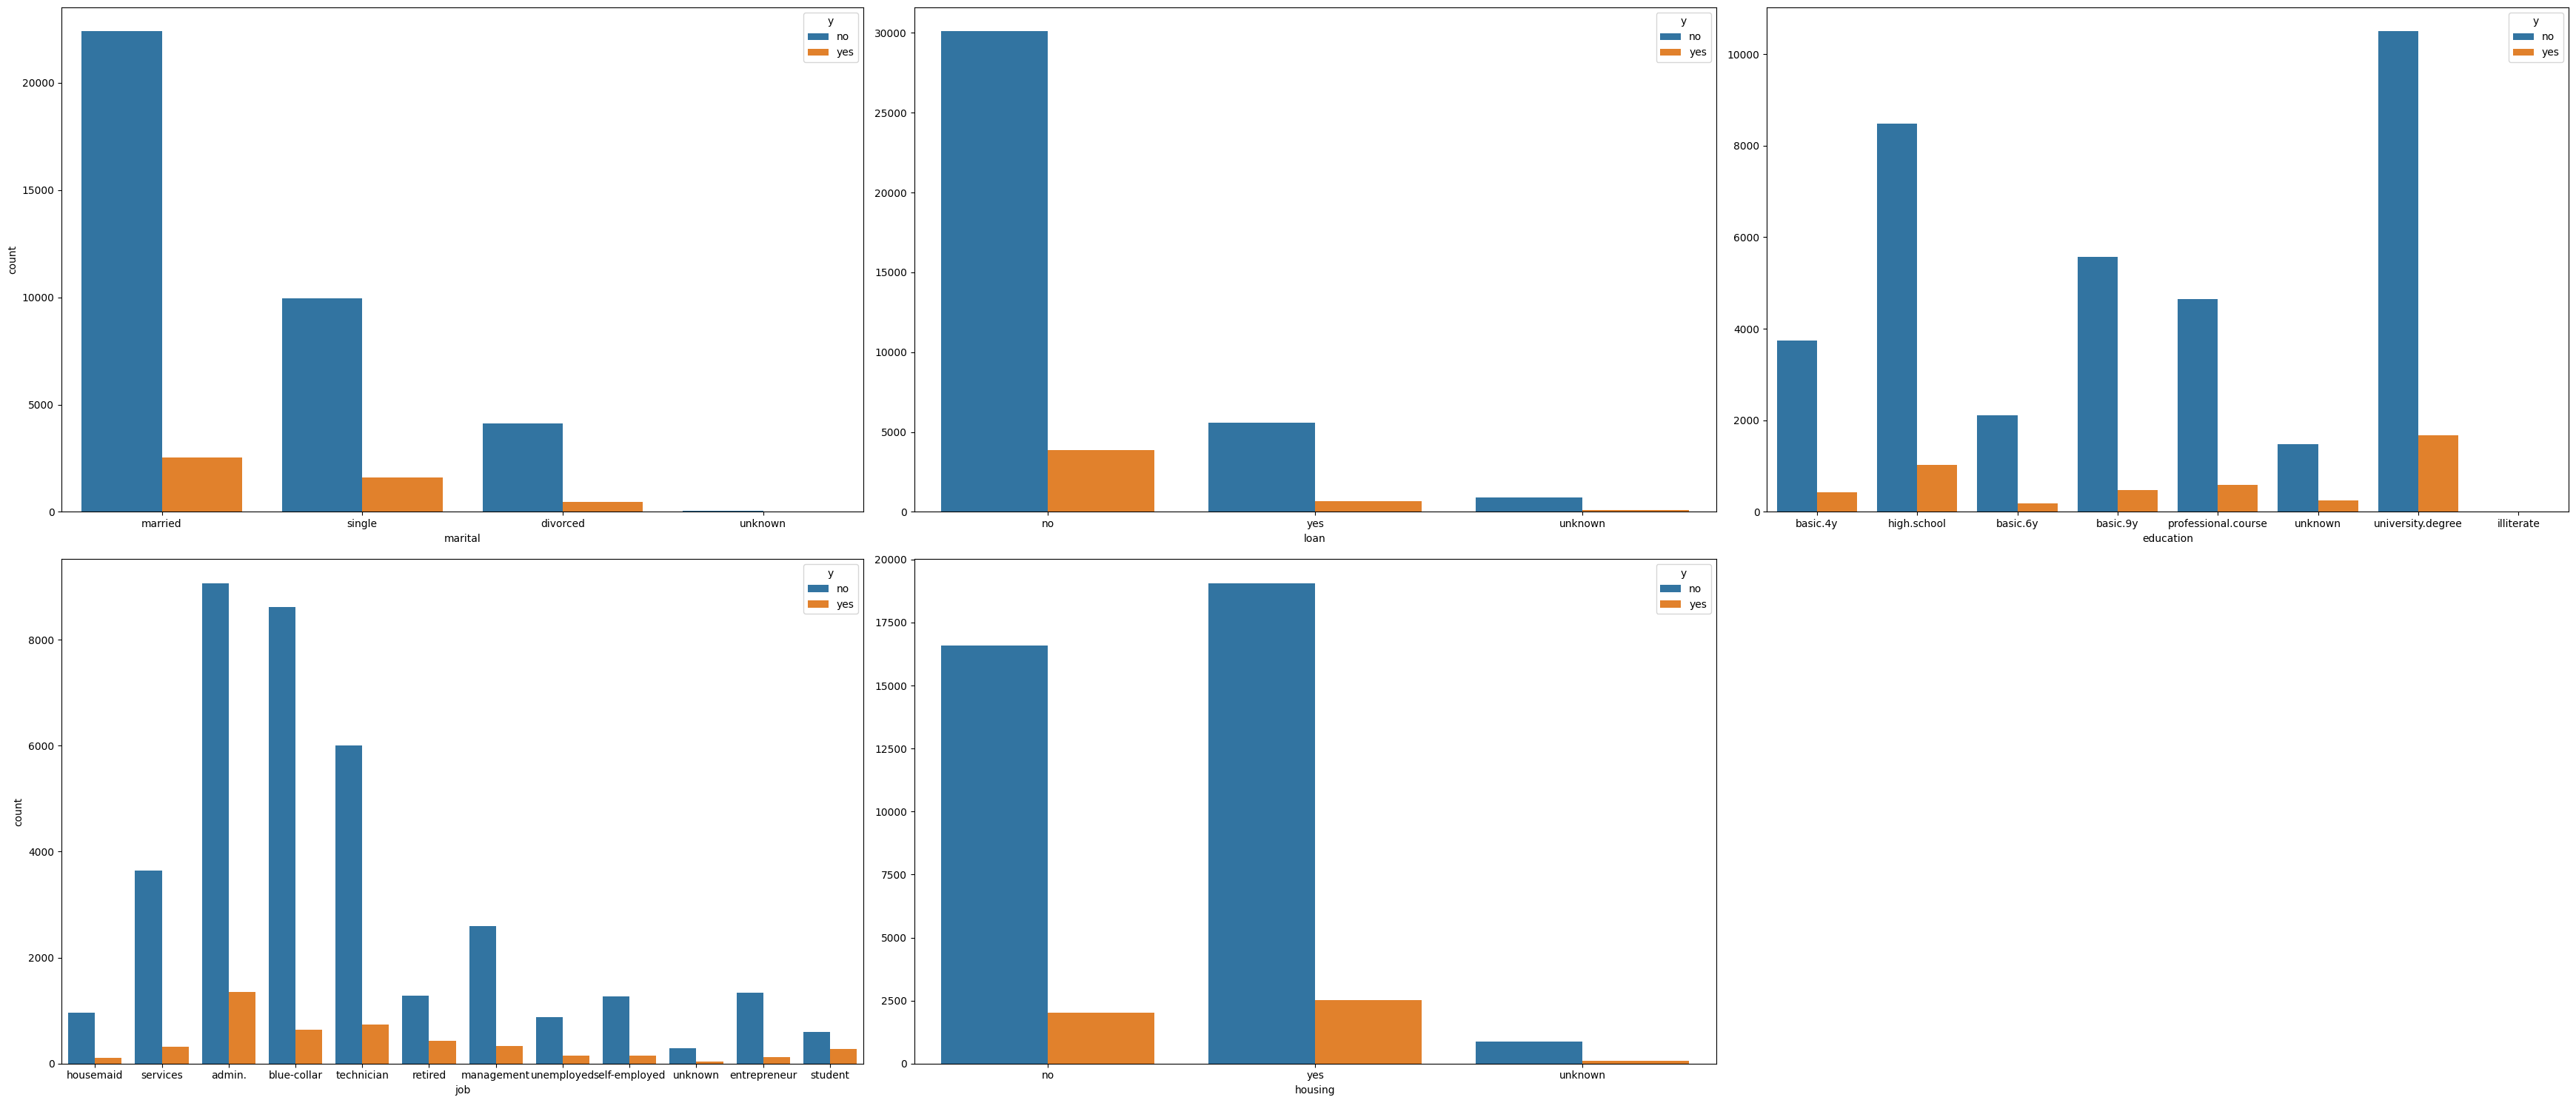

In [11]:
fig, axis = plt.subplots(2, 3, figsize = (35, 15))

sns.countplot(ax = axis[0, 0], data = df, x = "marital", hue = "y")
sns.countplot(ax = axis[0, 1], data = df, x = "loan", hue = "y").set(ylabel = None)
sns.countplot(ax = axis[0, 2], data = df, x = "education", hue = "y").set(ylabel = None)
sns.countplot(ax = axis[1, 0], data = df, x = "job", hue = "y")
sns.countplot(ax = axis[1, 1], data = df, x = "housing", hue = "y").set(ylabel = None)

plt.tight_layout()
fig.delaxes(axis[1, 2])

plt.show()

Las conclusiones que podemos sacar es que los cadas y con prestamos serian menos propensos a suscribirse, mientras que los solteros y las personas con educación superior tienen más probabilidad de suscribirse. Los que tienen trabajos como administrativos y tecnicos y los que tienen casa pueden estar mas receptivos a la oferta.

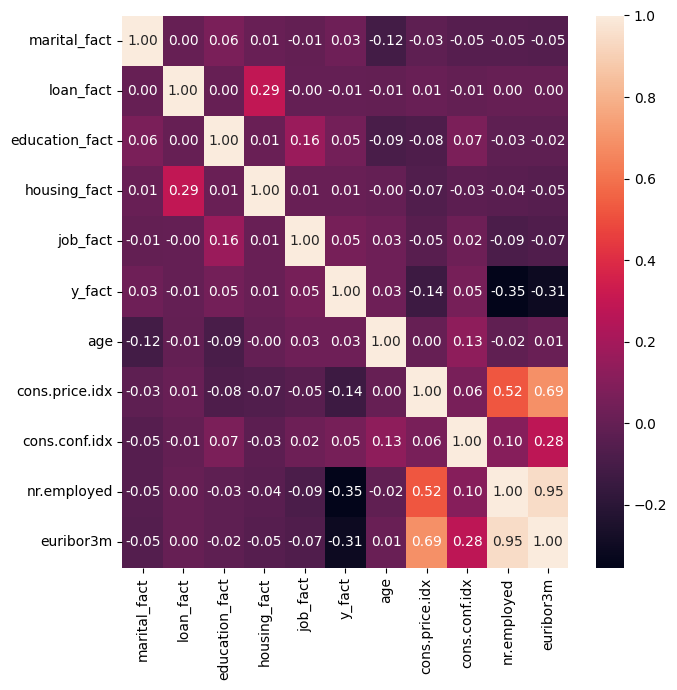

In [12]:
df["y_fact"] = pd.factorize(df["y"])[0]
df["marital_fact"] = pd.factorize(df["marital"])[0]
df["loan_fact"] = pd.factorize(df["loan"])[0]
df["education_fact"] = pd.factorize(df["education"])[0]
df["housing_fact"] = pd.factorize(df["housing"])[0]
df["job_fact"] = pd.factorize(df["job"])[0]

fig, axis = plt.subplots(figsize = (7, 7))

sns.heatmap(df[["marital_fact", "loan_fact", "education_fact", "housing_fact", "job_fact", "y_fact", "age", "cons.price.idx", "cons.conf.idx", "nr.employed", "euribor3m" ]].corr(), annot = True, fmt = ".2f")

plt.tight_layout()

plt.show()

De este gráfico destacaríamos la correlacion entre el prestamo y la casa, dato obvio ya que podriamos presuponer que estas personas tendrían una hipoteca y la relacion entre educacion y trabajo también obvia. Con respecto a la suscripción todas las correlaciones son bastante bajas, lo que indicaría que no hay ningún factor decisivo.

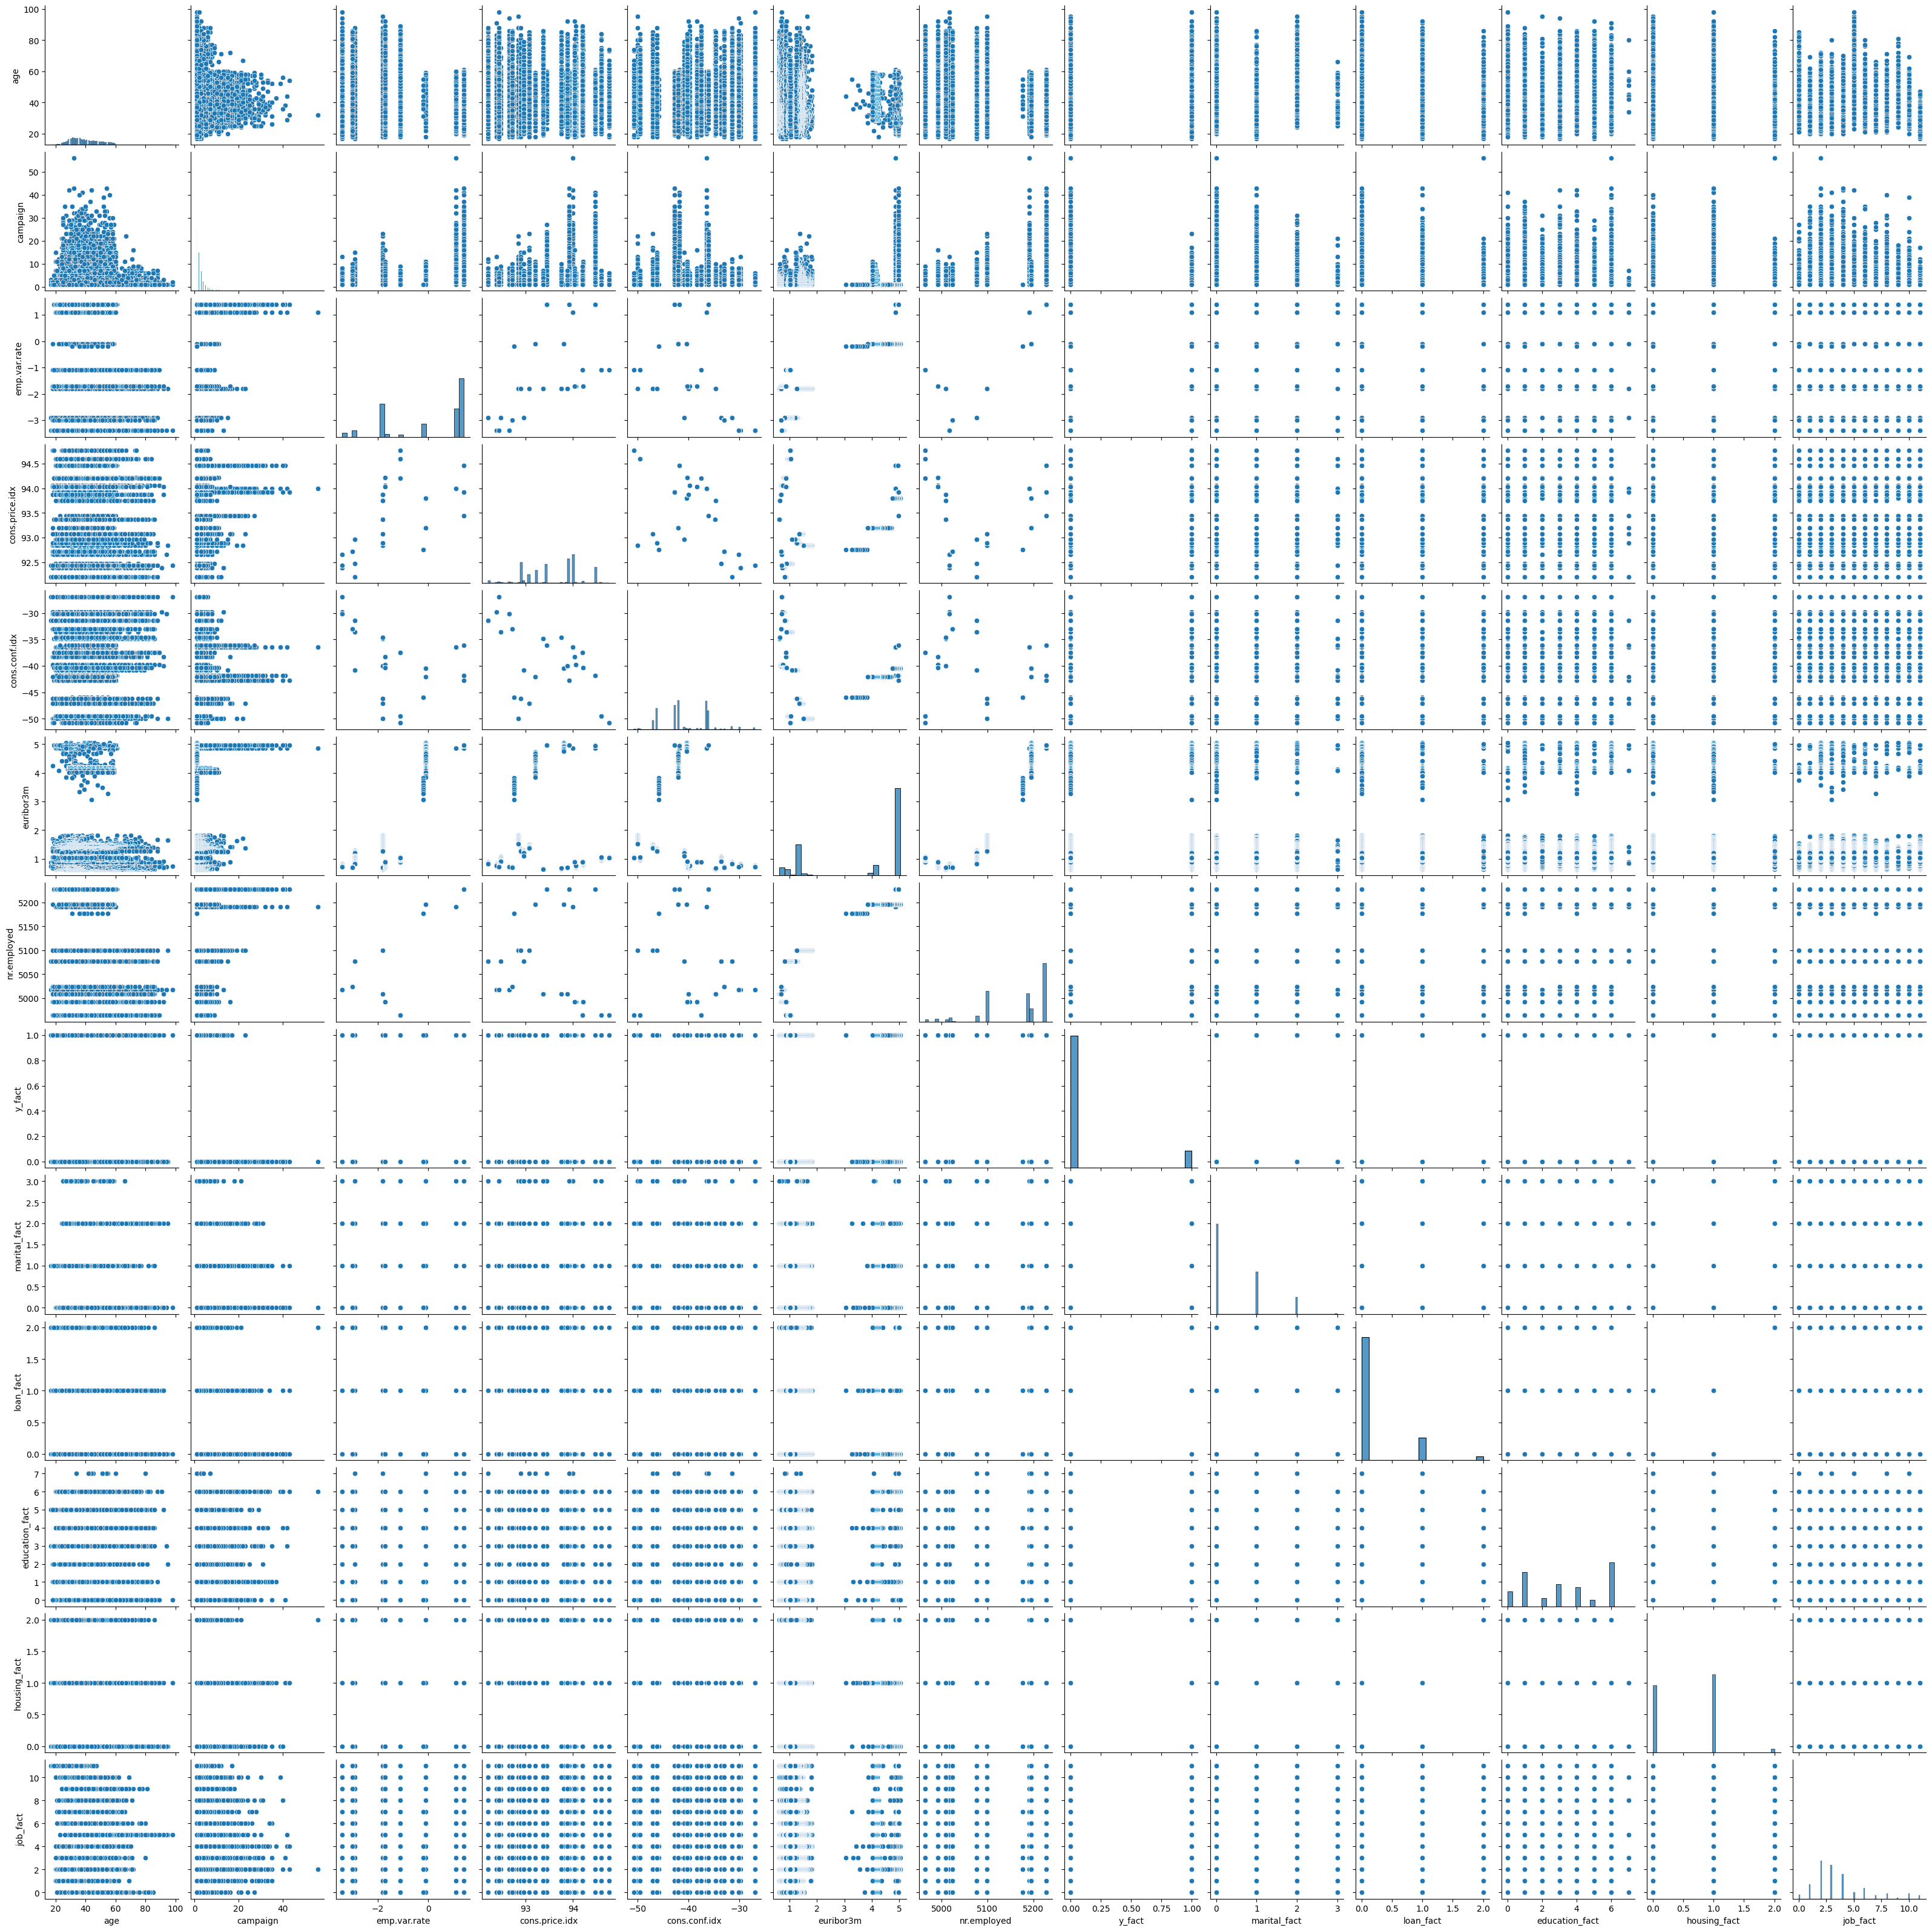

In [13]:
sns.pairplot(data = df)

In [14]:
#VALORES ATÍPICOS

df.describe().round(2)

,age,campaign,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y_fact,marital_fact,loan_fact,education_fact,housing_fact,job_fact
count,41176.00,41176.00,41176.00,41176.00,41176.00,41176.00,41176.00,41176.00,41176.00,41176.00,41176.00,41176.00,41176.00
mean,40.02,2.57,0.08,93.58,-40.50,3.62,5167.03,0.11,0.51,0.20,3.28,0.57,3.67
std,10.42,2.77,1.57,0.58,4.63,1.73,72.25,0.32,0.70,0.46,2.19,0.54,2.45
min,17.00,1.00,-3.40,92.20,-50.80,0.63,4963.60,0.00,0.00,0.00,0.00,0.00,0.00
25%,32.00,1.00,-1.80,93.08,-42.70,1.34,5099.10,0.00,0.00,0.00,1.00,0.00,2.00
50%,38.00,2.00,1.10,93.75,-41.80,4.86,5191.00,0.00,0.00,0.00,3.00,1.00,3.00
75%,47.00,3.00,1.40,93.99,-36.40,4.96,5228.10,0.00,1.00,0.00,6.00,1.00,4.00
max,98.00,56.00,1.40,94.77,-26.90,5.04,5228.10,1.00,3.00,2.00,7.00,2.00,11.00


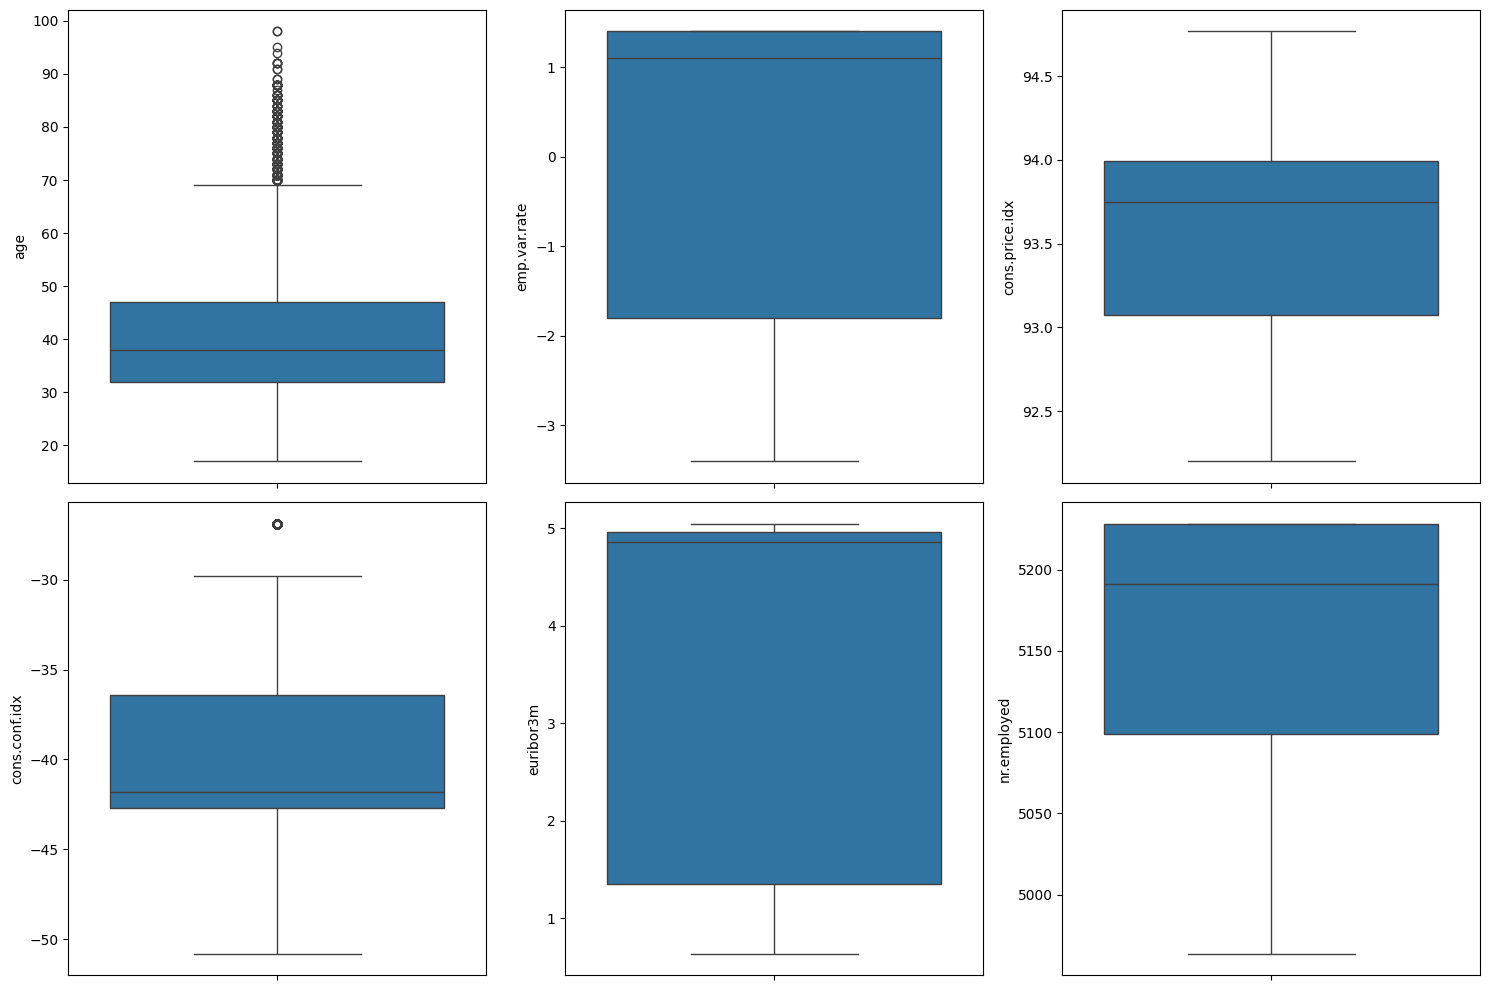

In [15]:
fig, axis = plt.subplots(2, 3, figsize = (15, 10))

sns.boxplot(ax = axis[0, 0], data = df, y = "age")
sns.boxplot(ax = axis[0, 1], data = df, y = "emp.var.rate")
sns.boxplot(ax = axis[0, 2], data = df, y = "cons.price.idx")
sns.boxplot(ax = axis[1, 0], data = df, y = "cons.conf.idx")
sns.boxplot(ax = axis[1, 1], data = df, y = "euribor3m")
sns.boxplot(ax = axis[1, 2], data = df, y = "nr.employed")



plt.tight_layout()

plt.show()

Vemos que hay valores atípicos en la edad y el euribor

In [16]:
Q1 = df['age'].quantile(0.25)
Q3 = df['age'].quantile(0.75)
IQR = Q3 - Q1

# Definir los límites inferior y superior
lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

print(f"Los límites superior e inferior para la búsqueda de outliers son {round(upper_limit, 2)} y {round(lower_limit, 2)}, con un rango intercuartílico de {round(IQR, 2)}")

Los límites superior e inferior para la búsqueda de outliers son 69.5 y 9.5, con un rango intercuartílico de 15.0


In [17]:
edad_alta = df[df["age"] >= 70]

edad_alta

,age,job,marital,education,housing,loan,contact,campaign,poutcome,emp.var.rate,...,cons.conf.idx,euribor3m,nr.employed,y,y_fact,marital_fact,loan_fact,education_fact,housing_fact,job_fact
27713,70,retired,divorced,basic.4y,yes,no,cellular,3,nonexistent,-1.8,...,-50.0,1.811,5099.1,yes,1,2,0,0,1,5
27757,76,retired,married,university.degree,no,yes,cellular,9,nonexistent,-1.8,...,-50.0,1.757,5099.1,no,0,0,1,6,0,5
27780,73,retired,married,university.degree,yes,no,cellular,1,failure,-1.8,...,-50.0,1.687,5099.1,no,0,0,0,6,1,5
27800,88,retired,divorced,basic.4y,yes,no,cellular,1,nonexistent,-1.8,...,-50.0,1.663,5099.1,no,0,2,0,0,1,5
27802,88,retired,divorced,basic.4y,no,no,cellular,2,nonexistent,-1.8,...,-50.0,1.663,5099.1,yes,1,2,0,0,0,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40986,84,retired,divorced,basic.4y,yes,yes,cellular,4,success,-1.1,...,-49.5,1.000,4963.6,no,0,2,1,0,1,5
40996,81,retired,married,basic.4y,yes,no,cellular,1,failure,-1.1,...,-49.5,1.016,4963.6,yes,1,0,0,0,1,5
41004,80,retired,married,professional.course,yes,no,cellular,1,failure,-1.1,...,-49.5,1.025,4963.6,yes,1,0,0,4,1,5
41183,73,retired,married,professional.course,yes,no,cellular,1,nonexistent,-1.1,...,-50.8,1.028,4963.6,yes,1,0,0,4,1,5


Los valores atípicos sería un 0,01 de la muestra por lo que los eliminariamos por que además no tendría mucho sentido enfocar esta campaña a personas de mas de 70 años.

In [18]:
df = df[df['age'] <= 70]

In [19]:
Q1 = df['nr.employed'].quantile(0.25)
Q3 = df['nr.employed'].quantile(0.75)
IQR = Q3 - Q1

# Definir los límites inferior y superior
lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

print(f"Los límites superior e inferior para la búsqueda de outliers son {round(upper_limit, 2)} y {round(lower_limit, 2)}, con un rango intercuartílico de {round(IQR, 2)}")

Los límites superior e inferior para la búsqueda de outliers son 5421.6 y 4905.6, con un rango intercuartílico de 129.0


In [20]:
cons_alto = df[df["nr.employed"] >= 5071.35]

cons_alto

,age,job,marital,education,housing,loan,contact,campaign,poutcome,emp.var.rate,...,cons.conf.idx,euribor3m,nr.employed,y,y_fact,marital_fact,loan_fact,education_fact,housing_fact,job_fact
0,56,housemaid,married,basic.4y,no,no,telephone,1,nonexistent,1.1,...,-36.4,4.857,5191.0,no,0,0,0,0,0,0
1,57,services,married,high.school,no,no,telephone,1,nonexistent,1.1,...,-36.4,4.857,5191.0,no,0,0,0,1,0,1
2,37,services,married,high.school,yes,no,telephone,1,nonexistent,1.1,...,-36.4,4.857,5191.0,no,0,0,0,1,1,1
3,40,admin.,married,basic.6y,no,no,telephone,1,nonexistent,1.1,...,-36.4,4.857,5191.0,no,0,0,0,2,0,2
4,56,services,married,high.school,no,yes,telephone,1,nonexistent,1.1,...,-36.4,4.857,5191.0,no,0,0,1,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37882,31,management,married,university.degree,yes,yes,cellular,2,nonexistent,-2.9,...,-31.4,0.821,5076.2,yes,1,0,1,6,1,6
37883,59,self-employed,married,university.degree,yes,no,telephone,1,nonexistent,-2.9,...,-31.4,0.821,5076.2,no,0,0,0,6,1,8
37884,63,retired,married,university.degree,yes,no,cellular,1,failure,-2.9,...,-31.4,0.821,5076.2,no,0,0,0,6,1,5
37885,34,admin.,married,university.degree,yes,no,cellular,1,nonexistent,-2.9,...,-31.4,0.821,5076.2,no,0,0,0,6,1,2


Sería un número muy bajo de valores atípicos por lo que los eliminariamos

In [21]:
df = df[df['nr.employed'] <= 5071.35]

In [22]:
#VALORES FALTANTES

df.isnull().sum().sort_values(ascending=False)


age               0
job               0
marital           0
education         0
housing           0
loan              0
contact           0
campaign          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
y_fact            0
marital_fact      0
loan_fact         0
education_fact    0
housing_fact      0
job_fact          0
dtype: int64

In [23]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
num_variables = ['marital_fact', 'loan_fact','education_fact', 'housing_fact', 'job_fact', 'age', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']
scaler.fit_transform(df[num_variables])

X_train_num_mm = scaler.transform(df[num_variables])
X_train_num_mm = pd.DataFrame(X_train_num_mm, index = df.index, columns = num_variables)


X_train_num_mm.head()

,marital_fact,loan_fact,education_fact,housing_fact,job_fact,age,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
37887,0.000000,0.0,1.000000,0.5,0.181818,0.679245,0.0,0.878661,0.444712,0.899833
37888,0.333333,0.5,1.000000,0.5,0.181818,0.283019,0.0,0.878661,0.444712,0.899833
37889,0.000000,0.0,0.833333,0.0,0.181818,0.660377,0.0,0.878661,0.444712,0.899833
37890,0.000000,0.0,0.333333,0.5,0.909091,0.415094,0.0,0.878661,0.444712,0.899833
37891,0.333333,0.0,1.000000,0.5,0.181818,0.283019,0.0,0.878661,0.444712,0.899833


In [24]:
from sklearn.preprocessing import LabelEncoder

X_train_cat_le = df.copy()
X_test_cat_le = df.copy()

label_encoder_job = LabelEncoder()
label_encoder_marital = LabelEncoder()
label_encoder_education = LabelEncoder()
label_encoder_housing = LabelEncoder()
label_encoder_loan = LabelEncoder()


# entreno el encoder con los datos de entrenamiento
label_encoder_job.fit(df['job'])
label_encoder_marital.fit(df['marital'])
label_encoder_education.fit(df['education'])
label_encoder_housing.fit(df['housing'])
label_encoder_loan.fit(df['loan'])

# aplico el encoder en ambos
X_train_cat_le['job_le'] = label_encoder_job.transform(df['job'])
X_train_cat_le['marital_le'] = label_encoder_marital.transform(df['marital'])
X_train_cat_le['education_le'] = label_encoder_education.transform(df['education'])
X_train_cat_le['housing_le'] = label_encoder_housing.transform(df['housing'])
X_train_cat_le['loan_le'] = label_encoder_loan.transform(df['loan'])


X_test_cat_le['job_le'] = label_encoder_job.transform(df['job'])
X_test_cat_le['marital_le'] = label_encoder_marital.transform(df['marital'])
X_test_cat_le['education_le'] = label_encoder_education.transform(df['education'])
X_test_cat_le['housing_le'] = label_encoder_housing.transform(df['housing'])
X_test_cat_le['loan_le'] = label_encoder_loan.transform(df['loan'])


X_train_cat_le.head(10)

,age,job,marital,education,housing,loan,contact,campaign,poutcome,emp.var.rate,...,marital_fact,loan_fact,education_fact,housing_fact,job_fact,job_le,marital_le,education_le,housing_le,loan_le
37887,53,admin.,married,university.degree,yes,no,cellular,5,nonexistent,-3.4,...,0,0,6,1,2,0,1,5,2,0
37888,32,admin.,single,university.degree,yes,yes,cellular,2,nonexistent,-3.4,...,1,1,6,1,2,0,2,5,2,2
37889,52,admin.,married,unknown,no,no,telephone,5,nonexistent,-3.4,...,0,0,5,0,2,0,1,6,0,0
37890,39,entrepreneur,married,basic.6y,yes,no,cellular,2,success,-3.4,...,0,0,2,1,10,2,1,1,2,0
37891,32,admin.,single,university.degree,yes,no,cellular,2,nonexistent,-3.4,...,1,0,6,1,2,0,2,5,2,0
37892,36,admin.,married,university.degree,yes,yes,cellular,2,nonexistent,-3.4,...,0,1,6,1,2,0,1,5,2,2
37893,52,admin.,married,unknown,no,no,telephone,13,failure,-3.4,...,0,0,5,0,2,0,1,6,0,0
37894,35,entrepreneur,married,high.school,no,no,cellular,2,nonexistent,-3.4,...,0,0,1,0,10,2,1,3,0,0
37895,48,technician,married,basic.9y,no,no,cellular,3,failure,-3.4,...,0,0,3,0,4,9,1,2,0,0
37896,27,management,single,university.degree,yes,no,cellular,2,success,-3.4,...,1,0,6,1,6,4,2,5,2,0


In [ ]:
#SELECIÓN DE CARACTERÍSTICAS
from sklearn.feature_selection import f_classif, SelectKBest
from sklearn.model_selection import train_test_split

selection_model = SelectKBest(score_func = f_classif, k = 5)







gjyjyjdyjjfjfthjftjhfthtjmgfgdzgzrdhhhhhh

X = X_train_num_mm  
y = df["y"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

selection_model.fit(X_train, y_train)
ix = selection_model.get_support()
X_train_sel = pd.DataFrame(selection_model.transform(X_train), columns = X_train.columns.values[ix])
X_test_sel = pd.DataFrame(selection_model.transform(X_test), columns = X_test.columns.values[ix])

X_train_sel.head()

,education_fact,age,cons.price.idx,cons.conf.idx,nr.employed
0,1.000000,0.452830,0.139866,0.744770,1.000000
1,1.000000,0.452830,0.573702,0.677824,0.752922
2,0.166667,0.150943,0.930486,0.054393,0.000000
3,0.333333,0.037736,0.762144,0.556485,0.000000
4,0.000000,0.056604,0.573702,0.677824,0.752922


In [26]:
selected_features = X_train.columns[selection_model.get_support()]

selected_features

Index(['education_fact', 'age', 'cons.price.idx', 'cons.conf.idx',
       'nr.employed'],
      dtype='object')

In [43]:
from sklearn.model_selection import train_test_split

X = X_train_cat_le[['age', 'cons.price.idx', 'cons.conf.idx', 'education_le', 'nr.employed']]
y = X_train_cat_le['y_fact'] 

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [44]:
X_test.shape

(602, 5)

In [45]:
X_train.shape

(2406, 5)

In [46]:
y_train

39097    0
39462    1
41048    0
40759    1
39446    1
        ..
39708    1
39108    0
39146    0
39317    0
38841    0
Name: y_fact, Length: 2406, dtype: int64

In [47]:
#REGRESIÓN LOGÍSTICA 
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()

model.fit(X_train, y_train)

LogisticRegression()

In [48]:
#predicción
y_pred = model.predict(X_test)
y_pred

array([0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0,
       1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1,
       0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1,
       0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1,
       1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0,
       0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1,
       0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1,
       0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0,
       0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1,
       0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1,

In [49]:
from sklearn.metrics import accuracy_score

y_pred_train = model.predict(X_train)

accuracy_score(y_train, y_pred_train)

0.5320033250207814

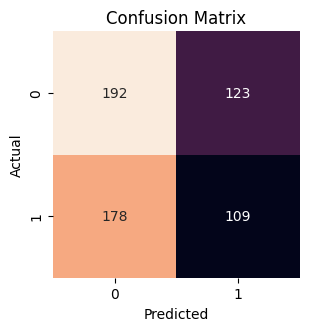

In [50]:
from sklearn.metrics import confusion_matrix
banco = confusion_matrix(y_test, y_pred)

# Dibujaremos esta matriz para hacerla más visual
cm_df = pd.DataFrame(banco)

plt.figure(figsize = (3, 3))
sns.heatmap(cm_df, annot=True, fmt="d", cbar=False)

plt.tight_layout()

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

CONCLUSIÓN DE LA MATRIZ
Verdaderos positivos: 246
Verdaderos negativos: 67
Falsos positivos: 215
Falsos negativos: 72


In [35]:
#OPTIMIZACIÓN DE DATOS 

def warn(*args, **kwargs):
    pass
import warnings
warnings.warn = warn

In [36]:
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
# genera el modelo
model = LogisticRegression()

# Definimos los parámetros que queremos ajustar a mano
hyperparams = {
    "C": [0.001, 0.01, 0.1, 1, 10, 100, 1000],
    "penalty": ["l1", "l2", "elasticnet", None],
    "solver": ["newton-cg", "lbfgs", "liblinear", "sag", "saga"]
}

grid = GridSearchCV(model, hyperparams, scoring = "accuracy", cv = 10)
grid

GridSearchCV(cv=10, estimator=LogisticRegression(),
             param_grid={'C': [0.001, 0.01, 0.1, 1, 10, 100, 1000],
                         'penalty': ['l1', 'l2', 'elasticnet', None],
                         'solver': ['newton-cg', 'lbfgs', 'liblinear', 'sag',
                                    'saga']},
             scoring='accuracy')

In [37]:
grid.fit(X_train, y_train)

print(f"Mejores hiperparámetros: {grid.best_params_}")

Mejores hiperparámetros: {'C': 0.001, 'penalty': 'l1', 'solver': 'liblinear'}


In [42]:
model_grid = LogisticRegression(penalty = "l1", C = 0.001, solver = "liblinear")
model_grid.fit(X_train, y_train)
y_pred = model_grid.predict(X_test)

grid_accuracy = accuracy_score(y_test, y_pred)
grid_accuracy

0.5232558139534884

Me ha bajado la precisión

In [39]:
import numpy as np
# Definimos los parámetros que queremos ajustar
hyperparams = {
    "C": np.logspace(-4, 4, 20),
    "penalty": ["l1", "l2", "elasticnet", None],
    "solver": ["newton-cg", "lbfgs", "liblinear", "sag", "saga"]
}

# Inicializamos la búsqueda aleatoria
random_search = RandomizedSearchCV(model, hyperparams, n_iter = 100, scoring = "accuracy", cv = 5, random_state = 42)
random_search

RandomizedSearchCV(cv=5, estimator=LogisticRegression(), n_iter=100,
                   param_distributions={'C': array([1.00000000e-04, 2.63665090e-04, 6.95192796e-04, 1.83298071e-03,
       4.83293024e-03, 1.27427499e-02, 3.35981829e-02, 8.85866790e-02,
       2.33572147e-01, 6.15848211e-01, 1.62377674e+00, 4.28133240e+00,
       1.12883789e+01, 2.97635144e+01, 7.84759970e+01, 2.06913808e+02,
       5.45559478e+02, 1.43844989e+03, 3.79269019e+03, 1.00000000e+04]),
                                        'penalty': ['l1', 'l2', 'elasticnet',
                                                    None],
                                        'solver': ['newton-cg', 'lbfgs',
                                                   'liblinear', 'sag',
                                                   'saga']},
                   random_state=42, scoring='accuracy')

In [40]:
random_search.fit(X_train, y_train)

print(f"Mejores hiperparámetros: {random_search.best_params_}")

Mejores hiperparámetros: {'solver': 'saga', 'penalty': 'l1', 'C': np.float64(0.03359818286283781)}


In [41]:
model_random_search = LogisticRegression(penalty = "l2", C = np.float64(0.03359818286283781), solver = "saga")
model_random_search.fit(X_train, y_train)
y_pred = model_random_search.predict(X_test)

random_search_accuracy = accuracy_score(y_test, y_pred)
random_search_accuracy

0.5232558139534884

Se queda igual que el anterior